
# M2M-100 (zh→en) — Baseline TF Training (Wuxia Domain)

**TFG Hugo Silvosa – Baseline NMT (M2M-100)**  
Este cuaderno entrena y evalúa un modelo **M2M-100** ("facebook/m2m100_418M") usando un dataset del dominio **wuxia** (chino->inglés) ya preparado en formato `datasets` (HF).






## 1) Preparación del entorno

In [1]:

import os, random, math
import numpy as np

import torch
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Nombre de la GPU:", torch.cuda.get_device_name(0))



CUDA disponible: True
Número de GPUs: 1
Nombre de la GPU: NVIDIA GeForce RTX 3060


> **Requisitos del dataset**: directorio HF Datasets con *splits* `train`, `validation`, `test` y columnas `zh` (chino) y `en` (inglés):  
> `processed_data/wuxia_zh_en_clean/`

In [2]:
# Configuración de carpetas para repositorio LOCAL
from pathlib import Path
BASE_DIR = Path.cwd().parent.parent
BASE_DIR.mkdir(exist_ok=True)

# Estructura del repositorio
for sub in ["evaluation", "models", "processed_data"]:
    (BASE_DIR / sub).mkdir(parents=True, exist_ok=True)

print("Base:", BASE_DIR.resolve())
print("Estructura creada (si no existía):")
for p in ["evaluation", "models", "proccesed_data"]:
    print(" -", (BASE_DIR / p).resolve())

# Nota: el dataset debe existir en: CORPUS/proccesed data/wuxia_zh_en_clean


Base: C:\Users\Usuario\Desktop\TFG\CORPUS
Estructura creada (si no existía):
 - C:\Users\Usuario\Desktop\TFG\CORPUS\evaluation
 - C:\Users\Usuario\Desktop\TFG\CORPUS\models
 - C:\Users\Usuario\Desktop\TFG\CORPUS\proccesed_data


## 2) Configuración

In [3]:
from dataclasses import dataclass

@dataclass
class Config:
    # Rutas en local
    dataset_dir: Path  = BASE_DIR / "processed_data" / "wuxia_zh_en_clean"   # <- carpeta con dataset HuggingFace 
    output_dir: Path   = BASE_DIR / "models" / "m2m100_wuxia"              # <- aquí se guardarán los runs/modelos
    ckpt_dir: Path     = BASE_DIR / "checkpoints"                          # <- checkpoints durante entrenamiento
    training_dir: Path = BASE_DIR / "training"         
    evaluation_dir: Path = BASE_DIR / "evaluation"
    translate_dir: Path = BASE_DIR / "evaluation" / "translate"
    translate_file: Path =  "m2m100.txt"
    results_file: Path = "results.txt"
    
    # Columnas del dataset
    src_col: str = "zh"
    tgt_col: str = "en"

    # Idiomas M2M-100
    src_lang: str = "zh"
    tgt_lang: str = "en"

    # Modelo
    model_ckpt: str = "facebook/m2m100_418M"

    # Entrenamiento
    seed: int = 42
    max_source_length: int = 128
    max_target_length: int = 128
    batch_size: int = 16
    epochs: int = 10
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    early_stopping_patience: int = 3

    fraction: float = 1

cfg = Config()
print(cfg)


Config(dataset_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/processed_data/wuxia_zh_en_clean'), output_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/models/m2m100_wuxia'), ckpt_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/checkpoints'), training_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/training'), evaluation_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation'), translate_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation/translate'), translate_file='m2m100.txt', results_file='results.txt', src_col='zh', tgt_col='en', src_lang='zh', tgt_lang='en', model_ckpt='facebook/m2m100_418M', seed=42, max_source_length=128, max_target_length=128, batch_size=16, epochs=10, learning_rate=2e-05, weight_decay=0.01, early_stopping_patience=3, fraction=1)


In [4]:
import random, numpy as np, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Semillas 
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)
os.environ["PYTHONHASHSEED"] = str(cfg.seed)


if device.type == "cuda":
    torch.cuda.manual_seed_all(cfg.seed)
    # Para reproducibilidad
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Semillas fijadas y backend configurado.")


Usando dispositivo: cuda
Semillas fijadas y backend configurado.


## 3) Cargar dataset (Hugging Face Datasets)

In [5]:

from datasets import load_from_disk, DatasetDict

assert os.path.isdir(cfg.dataset_dir), f"No se encuentra el dataset en: {cfg.dataset_dir}"
raw_ds: DatasetDict = load_from_disk(cfg.dataset_dir)
print(raw_ds)

# Validar columnas
def _check_cols(ds, src_col, tgt_col, split):
    cols = ds.column_names
    assert src_col in cols and tgt_col in cols, f"El split '{split}' debe contener columnas '{src_col}' y '{tgt_col}'. Columnas: {cols}"

for split in ["train", "validation", "test"]:
    assert split in raw_ds, f"Falta el split '{split}' en el dataset."
    _check_cols(raw_ds[split], cfg.src_col, cfg.tgt_col, split)

# testeos
def take_fraction(ds, frac, seed=42):
    if frac >= 1.0:
        return ds
    n = max(1, int(len(ds) * frac))
    return ds.shuffle(seed=seed).select(range(n))

train_ds = take_fraction(raw_ds["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(raw_ds["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(raw_ds["test"], cfg.fraction, seed=cfg.seed)

print(train_ds[:2])
print(f"Tam. train/val/test (fracción={cfg.fraction}):", len(train_ds), len(val_ds), len(test_ds))


DatasetDict({
    train: Dataset({
        features: ['zh', 'en'],
        num_rows: 417208
    })
    validation: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
    test: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
})
{'zh': ['第章 听到白小纯的话语，看到圣皇的迟疑，邪皇这里顿时呼吸一促，他目中刹那就露出凌厉之芒，右手猛的一挥，顿时那残破的红日，骤然幻化', '尤其是看到人群内的宋缺时，神算子立刻警惕，他当年在空城，是第一个跟随白小纯的，受到了重用，如今却成为了第二个，他顿时就视宋缺为竞争对手'], 'en': ['chapter- The Saint-Emperor hesitated, and the Vile-Emperor sucked in a breath, eyes flickering with cold light as he waved his hand to summon his damaged red sun', 'That was even more the case when he noticed Song Que among Bai Xiaochun’s men, which immediately got him even more on guard. Back in Sky City, Master God-Diviner had been the first to start following Bai Xiaochun again, and it had led to incredible benefits. Now, he was only the second to join him, which put Song Que in his sights as a major rival']}
Tam. train/val/test (fracción=1): 417208 52151 52151

## 4) Cargar tokenizador y modelo M2M-100 (zh→en)


In [6]:
from transformers import M2M100Tokenizer, M2M100ForConditionalGeneration

tokenizer = M2M100Tokenizer.from_pretrained(cfg.model_ckpt)
model = M2M100ForConditionalGeneration.from_pretrained(cfg.model_ckpt)
tokenizer.src_lang = cfg.src_lang
model.config.forced_bos_token_id = tokenizer.get_lang_id(cfg.tgt_lang)
model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo cargado: {cfg.model_ckpt}")
print(f"Parámetros totales: {n_params:,}")

# testeo
sample = {
    'zh': '江湖夜雨十年灯。',
    'en': 'Ten years of lamps in the night rain of the jianghu.'
}
inputs = tokenizer(sample['zh'], return_tensors='pt').to(device)
with torch.no_grad():
    out = model.generate(
        **inputs,
        max_length=cfg.max_target_length,
        num_beams=4, early_stopping=True,
        forced_bos_token_id=tokenizer.get_lang_id(cfg.tgt_lang)
    )
pred = tokenizer.decode(out[0], skip_special_tokens=True)
print('='*80)
print('ZH:', sample['zh'])
print('EN (ref):', sample['en'])
print('EN (pred):', pred)


Modelo cargado: facebook/m2m100_418M
Parámetros totales: 483,905,536


c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\transformers\generation\utils.py:1715: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


ZH: 江湖夜雨十年灯。
EN (ref): Ten years of lamps in the night rain of the jianghu.
EN (pred): A decade of rain light.


## 5) Preprocesamiento y tokenización

In [7]:
# Función para tokenizar M2M-100
def preprocess_function(examples):
    # importante fijar idiomas en cada llamada
    tokenizer.src_lang = cfg.src_lang         # source 
    # Para tokenizar labels con text_target se usa tgt_lang
    try:
        tokenizer.tgt_lang = cfg.tgt_lang     # target
    except Exception:
        pass

    
    model_inputs = tokenizer(
        examples[cfg.src_col],
        max_length=cfg.max_source_length,
        padding=False,
        truncation=True
    )

    try:
        labels = tokenizer(
            text_target=examples[cfg.tgt_col],
            max_length=cfg.max_target_length,
            padding=False,
            truncation=True
        )
    except TypeError:
        # Compatibilidad con transformers antiguos
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(
                examples[cfg.tgt_col],
                max_length=cfg.max_target_length,
                padding=False,
                truncation=True
            )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Aplicar tokenización a todo el dataset
tokenized_datasets = raw_ds.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_ds["train"].column_names
)

train_ds = take_fraction(tokenized_datasets["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(tokenized_datasets["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(tokenized_datasets["test"], cfg.fraction, seed=cfg.seed)

print(train_ds[0])


Map:   0%|          | 0/52151 [00:00<?, ? examples/s]

{'input_ids': [128102, 36741, 31659, 22, 18502, 1885, 10195, 2564, 89547, 36664, 29163, 4, 16501, 60116, 44253, 80, 117835, 21082, 4, 91101, 44253, 37256, 51147, 3720, 27321, 32282, 971, 51262, 4, 1957, 8257, 1203, 124909, 5133, 2354, 26528, 1799, 96983, 118223, 4326, 121938, 4, 49121, 2382, 104686, 9600, 116861, 4, 51147, 3720, 5133, 21035, 22105, 80, 26512, 1273, 4, 122102, 11318, 79929, 3453, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [128022, 74070, 436, 7, 1658, 12369, 7, 35701, 1215, 178, 30318, 1776, 241, 4, 1019, 1197, 141, 421, 7, 35701, 1215, 178, 248, 119237, 28, 8, 120052, 4, 122301, 109150, 918, 150, 9792, 124249, 86770, 285, 1307, 84848, 241, 14810, 3972, 128, 4088, 5722, 14810, 9627, 117626, 5091, 4292, 2]}


## 6) Data collator

In [8]:
from transformers import DataCollatorForSeq2Seq

# Data collator para "facebook/m2m100_418M"
# Se encarga de alinear dinámicamente las secuencias y crear batches listos para el modelo
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",   
    return_tensors="pt"
)

# Ejemplo de batch
batch = data_collator([train_ds[i] for i in range(2)])
for k, v in batch.items():
    print(f"{k}: shape={v.shape}, dtype={v.dtype}")

input_ids: shape=torch.Size([2, 62]), dtype=torch.int64
attention_mask: shape=torch.Size([2, 62]), dtype=torch.int64
labels: shape=torch.Size([2, 89]), dtype=torch.int64


## 7) Configuración de entrenamiento PyTorch + Seq2SeqTrainer



> **Por defecto**          
> **Optimizador**: `AdamW` (con LR=2e-5, weight decay=0.01) de `Seq2SeqTrainer`   
> **Loss**: `CrossEntropyLoss` (token-level) de AutoModelForSeq2SeqLM (`M2M100`)  





In [9]:

from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

# Carpeta para resultados
run_dir = cfg.output_dir
run_dir.mkdir(parents=True, exist_ok=True)


training_args = Seq2SeqTrainingArguments(
    output_dir=str(run_dir),
    overwrite_output_dir=True,
    eval_strategy="epoch",                  # Evaluar al final de cada epoch
    save_strategy="epoch",                  # Guardar checkpoint por epoch
    save_total_limit=3,                      # Mxa nº de checkpoints guardados
    learning_rate=cfg.learning_rate,
    num_train_epochs=cfg.epochs,
    per_device_train_batch_size=cfg.batch_size,
    per_device_eval_batch_size=cfg.batch_size,
    weight_decay=cfg.weight_decay,
    logging_dir=str(run_dir / "logs"),
    logging_strategy="steps",
    logging_steps=50,
    predict_with_generate=True,              # Generar secuencias en validación
    fp16=torch.cuda.is_available(),          # Precisión mixta si hay GPU
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)

# Trainer para Seq2Seq
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator
)

print(" Seq2SeqTrainer configurado (PyTorch).")


 Seq2SeqTrainer configurado (PyTorch).


## 8) Cargar mejor checkpoint del modelo entrenado + Gráficas de entrenamiento


In [10]:

from transformers import M2M100Tokenizer, M2M100ForConditionalGeneration
import torch, gc
try:
    del model; del tokenizer
except Exception:
    pass
gc.collect(); torch.cuda.empty_cache()

best_ckpt_path = getattr(trainer.state, 'best_model_checkpoint', None)
if best_ckpt_path is None:
    best_ckpt_path = cfg.output_dir
print(f"Cargando modelo desde: {best_ckpt_path}")
tokenizer = M2M100Tokenizer.from_pretrained(best_ckpt_path)
model = M2M100ForConditionalGeneration.from_pretrained(best_ckpt_path).to(device)
tokenizer.src_lang = cfg.src_lang
model.config.forced_bos_token_id = tokenizer.get_lang_id(cfg.tgt_lang)
print('Mejor modelo y tokenizer cargados.')


Cargando modelo desde: c:\Users\Usuario\Desktop\TFG\CORPUS\models\m2m100_wuxia
Mejor modelo y tokenizer cargados.


 Información del entrenamiento:
  model_name: facebook/m2m100_418M
  epochs: 10
  batch_size: 16
  learning_rate: 2e-05
  weight_decay: 0.01
  train_size: 417208
  val_size: 52151
  metrics: {'train_runtime': 110844.6959, 'train_samples_per_second': 37.639, 'train_steps_per_second': 2.352, 'total_flos': 5.801929217247805e+17, 'train_loss': 1.0529115749623332, 'epoch': 10.0}

 Métricas finales de entrenamiento:
  epoch: 10.0
  total_flos: 5.801929217247805e+17
  train_loss: 1.0529115749623332
  train_runtime: 110844.6959
  train_samples_per_second: 37.639
  train_steps_per_second: 2.352

 Mejor checkpoint: c:\Users\Usuario\Desktop\TFG\CORPUS\models\m2m100_wuxia\checkpoint-260760


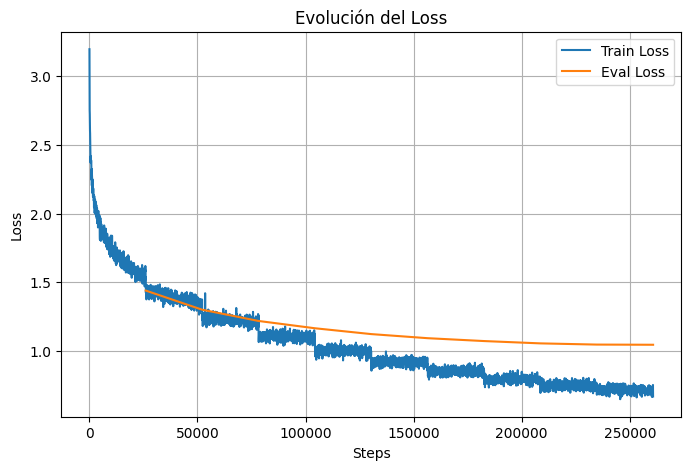

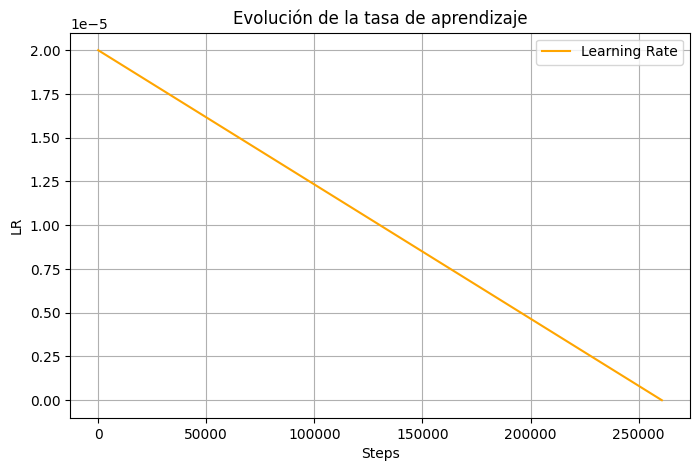

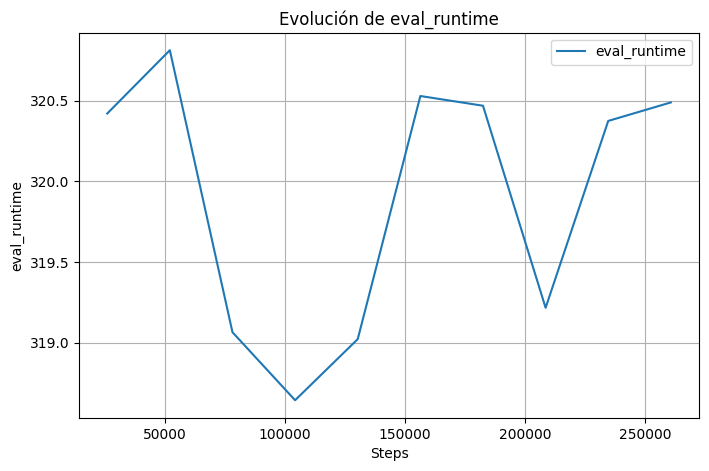

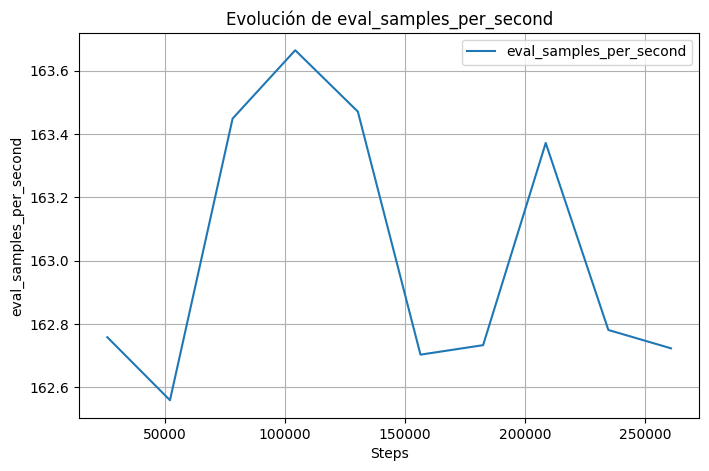

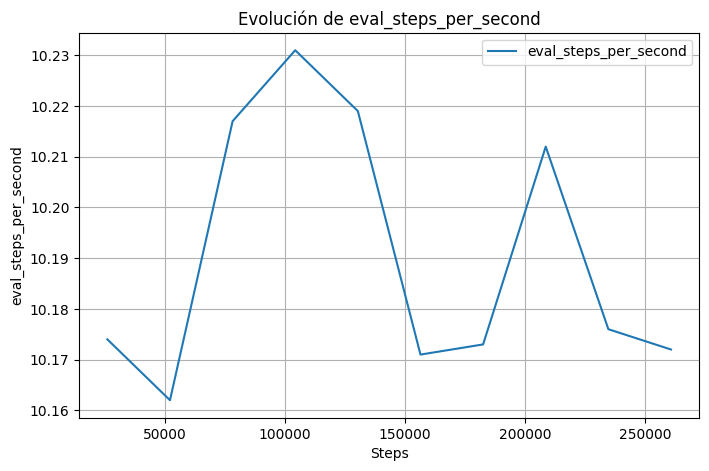

In [13]:
## Mostrar toda la información y gráficas del entrenamiento guardado

import json
import matplotlib.pyplot as plt
from pathlib import Path

#  info de la run 
run_info_path = Path(cfg.output_dir) / "run_info.json"
if run_info_path.exists():
    with open(run_info_path, "r", encoding="utf-8") as f:
        run_info = json.load(f)
    print(" Información del entrenamiento:")
    for k, v in run_info.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {run_info_path}")

#  métricas finales 
metrics_path = Path(cfg.output_dir) / "train_results.json"
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        train_metrics = json.load(f)
    print("\n Métricas finales de entrenamiento:")
    for k, v in train_metrics.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {metrics_path}")

#  trainer_state.json para histórico de entrenamiento 
log_history_path = Path(cfg.output_dir) / "trainer_state.json"
if log_history_path.exists():
    with open(log_history_path, "r", encoding="utf-8") as f:
        trainer_state = json.load(f)

    # Info del mejor checkpoint
    best_ckpt = trainer_state.get("best_model_checkpoint", None)
    if best_ckpt:
        print(f"\n Mejor checkpoint: {best_ckpt}")
    else:
        print("\n No se encontró información del mejor checkpoint.")

    # Historial de métricas
    log_history = trainer_state.get("log_history", [])

    # Extraer métricas y pasos
    steps_train = [entry["step"] for entry in log_history if "loss" in entry]
    train_loss = [entry["loss"] for entry in log_history if "loss" in entry]

    steps_eval = [entry["step"] for entry in log_history if "eval_loss" in entry]
    eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

    learning_rates = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]
    steps_lr = [entry["step"] for entry in log_history if "learning_rate" in entry]

    #  métricas adicionales
    extra_metrics = {}
    for entry in log_history:
        for k, v in entry.items():
            if k.startswith("eval_") and k not in ["eval_loss"]:
                extra_metrics.setdefault(k, {"steps": [], "values": []})
                extra_metrics[k]["steps"].append(entry["step"])
                extra_metrics[k]["values"].append(v)

    # Gráfica loss 
    plt.figure(figsize=(8,5))
    plt.plot(steps_train, train_loss, label="Train Loss")
    plt.plot(steps_eval, eval_loss, label="Eval Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Evolución del Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráfica learning rate 
    if learning_rates:
        plt.figure(figsize=(8,5))
        plt.plot(steps_lr, learning_rates, label="Learning Rate", color="orange")
        plt.xlabel("Steps")
        plt.ylabel("LR")
        plt.title("Evolución de la tasa de aprendizaje")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Gráficas de métricas adicionales 
    for metric_name, data in extra_metrics.items():
        plt.figure(figsize=(8,5))
        plt.plot(data["steps"], data["values"], label=metric_name)
        plt.xlabel("Steps")
        plt.ylabel(metric_name)
        plt.title(f"Evolución de {metric_name}")
        plt.legend()
        plt.grid(True)
        plt.show()

else:
    print(f"No se encontró {log_history_path}")

## 9) Evaluación (SacreBLEU, chrF, TER, ROUGE-L, METEOR)

In [ ]:

from tqdm.auto import tqdm
import sacrebleu
from sacrebleu.metrics import CHRF, TER
from rouge_score import rouge_scorer
import nltk
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import wordpunct_tokenize
import numpy as np
import torch

import time
start = time.time()
# Descargar recursos de NLTK para METEOR
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Parámetros 
EVAL_MAX_SAMPLES = None        # None = todo el split
PRED_BEAMS = 4
BATCH_EVAL = max(1, cfg.batch_size // 2)

# Comprobaciones 
assert 'model' in globals(), "No se encontró `model`. Carga el modelo antes."
assert 'tokenizer' in globals(), "No se encontró `tokenizer`. Cárgalo antes."
assert 'val_ds' in globals() and 'test_ds' in globals(), "Faltan `val_ds` y/o `test_ds`."
assert 'cfg' in globals(), "Falta `cfg`."

# Asegurar pad_token_id
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token_id = tokenizer.eos_token_id


eval_raw = test_ds if len(test_ds) > 0 else val_ds
n_total = len(eval_raw)
n_eval = n_total if (EVAL_MAX_SAMPLES is None) else min(n_total, int(EVAL_MAX_SAMPLES))
assert n_eval > 0, "No hay ejemplos para evaluar."
def decode_ids_to_text(dataset, id_col):
    return [
        tokenizer.decode(ids, skip_special_tokens=True)
        for ids in dataset[id_col]
    ]

src_texts = decode_ids_to_text(eval_raw, "input_ids")[:n_eval]
ref_texts = decode_ids_to_text(eval_raw, "labels")[:n_eval]


# Generación por lotes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def batched_generate(texts, batch_size=8, max_length=128, num_beams=4):
    preds = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=cfg.max_source_length
            ).to(device)
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                num_beams=num_beams,
                early_stopping=True,
                forced_bos_token_id=tokenizer.get_lang_id(cfg.tgt_lang)
            )
            preds.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
    return preds

preds = batched_generate(
    src_texts,
    batch_size=BATCH_EVAL,
    max_length=cfg.max_target_length,
    num_beams=PRED_BEAMS
)

#  Métricas 
bleu_corpus = sacrebleu.corpus_bleu(preds, [ref_texts]).score

chrf_metric = CHRF(word_order=2)
chrf_corpus = chrf_metric.corpus_score(preds, [ref_texts]).score

ter_metric = TER()
ter_corpus = ter_metric.corpus_score(preds, [ref_texts]).score

def compute_rougeL_f1(hyp_list, ref_list):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    f1s = []
    for h, r in zip(hyp_list, ref_list):
        s = scorer.score(r, h)
        f1s.append(s['rougeL'].fmeasure)
    return float(np.mean(f1s)) * 100.0
rougeL_f1 = compute_rougeL_f1(preds, ref_texts)

def compute_meteor(hyp_list, ref_list):
    scores = []
    for hyp, ref in zip(hyp_list, ref_list):
        hyp_tok = wordpunct_tokenize(hyp) if isinstance(hyp, str) else hyp
        ref_tok = wordpunct_tokenize(ref) if isinstance(ref, str) else ref
        scores.append(meteor_score([ref_tok], hyp_tok))
    return float(np.mean(scores)) * 100.0
meteor_avg = compute_meteor(preds, ref_texts)

end_time = time.time()

results = {
    "model" : cfg.model_ckpt,
    "n_eval": n_eval,
    "num_beams": PRED_BEAMS,
    "batch_eval": BATCH_EVAL,
    "sacrebleu": round(bleu_corpus, 4),
    "chrf2": round(chrf_corpus, 4),
    "ter": round(ter_corpus, 4),
    "rougeL_f1": round(rougeL_f1, 4),
    "meteor": round(meteor_avg, 4), 
    "execution_time": round(end_time - start, 2)
}
os.makedirs(cfg.evaluation_dir, exist_ok=True)

res_file = os.path.join(cfg.evaluation_dir, cfg.results_file)

with open(res_file, "a", encoding="utf-8") as f:
    f.write("\n")
    f.write(json.dumps(results, ensure_ascii=False, indent=4))

print(results)


  0%|          | 0/6519 [00:00<?, ?it/s]

c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\transformers\generation\utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


{'n_eval': 52151, 'num_beams': 4, 'batch_eval': 8, 'sacrebleu': 31.9754, 'chrf2': 52.2431, 'ter': 60.6851, 'rougeL_f1': 59.289, 'meteor': 58.4991}


## 10) Muestra cualitativa (n ejemplos aleatorios)

In [ ]:
import random
import torch


n_show = 100
idxs = random.sample(range(len(eval_raw)), k=min(n_show, len(eval_raw)))

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for i in idxs:
    # Decodificar texto fuente y referencia desde dataset tokenizado
    zh = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
    en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

    # Tokenizar entrada y mover a dispositivo
    inputs = tokenizer(zh, return_tensors="pt").to(device)

    # Generar traducción
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_length=cfg.max_target_length,
            num_beams=4,
            early_stopping=True,
            forced_bos_token_id=tokenizer.get_lang_id(cfg.tgt_lang)
        )

    en_pred = tokenizer.decode(out[0], skip_special_tokens=True)

    print("="*80)
    print("ZH:", zh)
    print("EN (ref):", en_ref)
    print("EN (pred):", en_pred)


ZH: 人女仙们还未来得及细看,毛十二就分别派发虫
EN (ref): Before the mermaid Gu Immortals looked at them closely, Twelfth Hair already handed out Gu worms
EN (pred): Before the female immortals had time to look into it, Twelfth Hair sent their hair worms
ZH: 东方余亮听了边丝轩的汇报之后,心中对方源的重视程度,又拔升一个档次
EN (ref): Dong Fang Yu Liang heard Bian Si Xuan's report and raised his evaluation of Fang Yuan
EN (pred): After Dong Fang Yu Liang heard Bian Si Xuan's report, his importance towards Fang Yuan rose by another level
ZH: 方源也不意外。 这里毕竟是梦境,和现实有着区别
EN (ref): Fang Yuan was not surprised, this was a dream realm after all, it was different from the real world
EN (pred): Fang Yuan was not surprised, this was a dream realm after all, it was different from reality
ZH: 天尊的法旨,让整个通天大陆震动,所有宗门的修士一个个或是自愿,或是无奈,都不由自主的参与到了这场备战之中
EN (ref): The Celestial’s Dharmic decree sent all of the lands of Heavenspan into action. Whether they wanted to or not, all cultivators in all sects were to participate in the war effort
EN (pred): The Celestial’s

In [ ]:
from tqdm import tqdm

os.makedirs(cfg.translate_dir, exist_ok=True)
translate_path = os.path.join(cfg.translate_dir, cfg.translate_file)

with open(translate_path, "w", encoding="utf-8") as f:
    for i in tqdm(range(len(eval_raw))):
        zh = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
        en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

        inputs = tokenizer(zh, return_tensors="pt").to(device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_length=cfg.max_target_length,
                num_beams=4,
                early_stopping=True,
                forced_bos_token_id=tokenizer.get_lang_id(cfg.tgt_lang)
            )

        en_pred = tokenizer.decode(out[0], skip_special_tokens=True)

        # Guardar en el archivo
        f.write("="*80 + "\n")
        f.write("ZH: " + zh + "\n")
        f.write("EN (ref): " + en_ref + "\n")
        f.write("EN (pred): " + en_pred + "\n\n")


KeyboardInterrupt: 

In [11]:

# ==============================================================================
# CÓDIGO PARA EXTRAER MÉTRICAS DE DIFICULTAD (DATA CARTOGRAPHY)
# Añadir al final de cada notebook
# ==============================================================================

import torch
import pandas as pd
import sacrebleu
from tqdm.auto import tqdm
from sacrebleu.metrics import CHRF
# 1. Configuración
# ----------------
BATCH_SIZE = 64  # Aumenta si tienes VRAM, disminuye si da OOM
OUTPUT_FILE = f"scores_{cfg.model_ckpt.replace('/', '_')}.csv"
SRC_COL = cfg.src_col 
TGT_COL = cfg.tgt_col

print(f"--> Iniciando inferencia sobre el TRAIN SET para: {cfg.model_ckpt}")
print(f"--> Archivo de salida: {OUTPUT_FILE}")

# 2. Preparar Modelo
# ------------------
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Asegurar configuración de idioma para modelos multilingües (mBART, M2M100)
if hasattr(tokenizer, "src_lang") and hasattr(cfg, "src_lang"):
    tokenizer.src_lang = cfg.src_lang
# Para mBART/M2M100 forzamos el token de inicio si es necesario
if hasattr(model.config, "forced_bos_token_id") and hasattr(tokenizer, "lang_code_to_id"):
    try:
        # Intentar obtener el ID del idioma target
        lang_id = tokenizer.lang_code_to_id.get(cfg.tgt_lang, None)
        if lang_id is not None:
            model.config.forced_bos_token_id = lang_id
    except:
        pass

# 3. Loop de Inferencia sobre Train
# ---------------------------------
# Usamos raw_ds['train'] para tener el texto crudo y calcular BLEU real
dataset = raw_ds['train'] 
# dataset = dataset.select(range(1000)) # DESCOMENTAR PARA PROBAR RAPIDO

results_indices = []
results_scores = []

# Iterar por batches
for i in tqdm(range(0, len(dataset), BATCH_SIZE), desc="Generando"):
    batch = dataset[i : i + BATCH_SIZE]
    src_texts = batch[SRC_COL]
    tgt_texts = batch[TGT_COL] # Referencias reales
    
    # a) Tokenizar
    inputs = tokenizer(
        src_texts, 
        padding=True, 
        truncation=True, 
        max_length=cfg.max_source_length, 
        return_tensors="pt"
    ).to(device)
    
    # b) Generar (Greedy Search para velocidad)
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            max_new_tokens=cfg.max_target_length, 
            num_beams=1, 
            do_sample=False,
            early_stopping=False
        )
    
    # c) Decodificar
    decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    chrf_metric = CHRF(word_order=2)
    # d) Calcular Sentence-chrf
    for idx, (pred, ref) in enumerate(zip(decoded_preds, tgt_texts)):
        

        score = sacrebleu.sentence_chrf(pred, [ref]).score        
        # Guardar el índice original del dataset y el score
        results_indices.append(i + idx)
        results_scores.append(score)

# 4. Guardar Resultados
# ---------------------
df_scores = pd.DataFrame({
    'id': results_indices,
    'chrf': results_scores
})

# Guardamos en la carpeta de processed_data o donde prefieras
save_path = BASE_DIR / "processed_data" / OUTPUT_FILE
df_scores.to_csv(save_path, index=False)
print(f" Scores guardados en: {save_path}")

--> Iniciando inferencia sobre el TRAIN SET para: facebook/m2m100_418M
--> Archivo de salida: scores_facebook_m2m100_418M.csv


Generando:   0%|          | 0/6519 [00:00<?, ?it/s]

 Scores guardados en: c:\Users\Usuario\Desktop\TFG\CORPUS\processed_data\scores_facebook_m2m100_418M.csv
